<a href="https://colab.research.google.com/github/Janpu-Hou/Green-Learning-Basic/blob/main/IOT23_SLM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Load Dataset
2. Saab Transform
3. DFT Pruning & Balancing
4. Train/Test Split
5. SLM Fit & Predict
Full Pipeline Test Accuracy: 93.92%
6. Plot & Save Confusion Matrix
Saved confusion matrix plot to 'slm_confusion_matrix.png'!


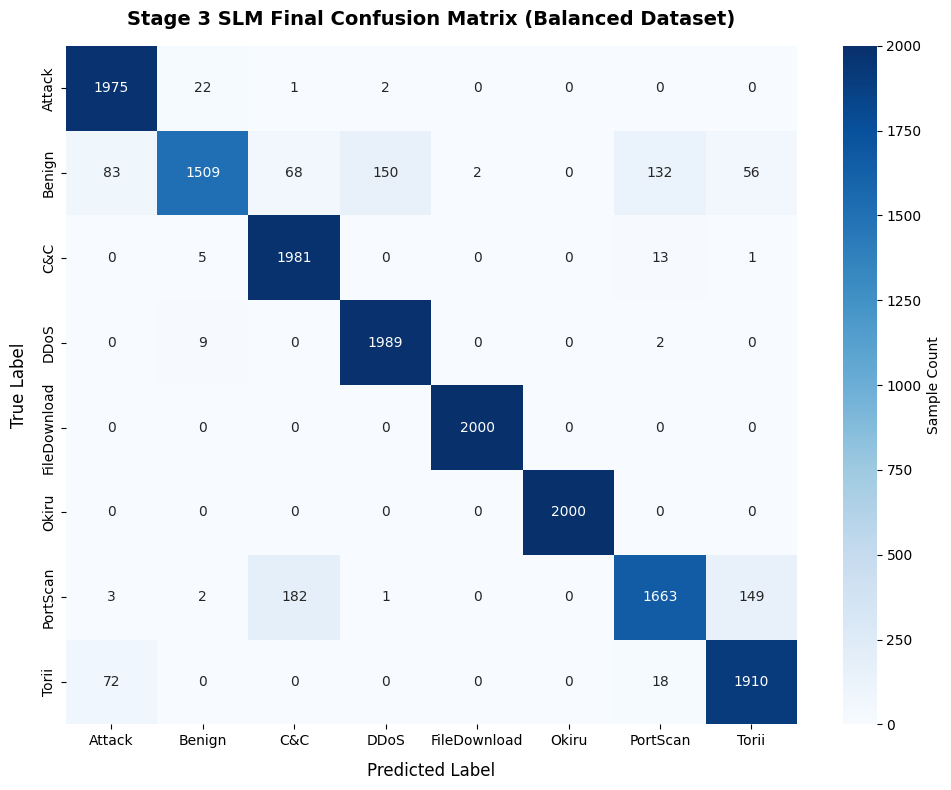

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.utils import resample


# ==========================================
# STAGE 1: Saab Subspace Feature Extraction
# ==========================================
def stage1_saab_transform(df_raw, n_components=16):
    exclude_cols = ['label', 'detailed-label', 'id.orig_h', 'id.resp_h']
    numeric_cols = [c for c in df_raw.columns if c not in exclude_cols and pd.api.types.is_numeric_dtype(df_raw[c])]

    X_raw = df_raw[numeric_cols].fillna(0).values
    y = df_raw['label'].values

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_raw)

    pca = PCA(n_components=n_components, random_state=42)
    X_saab = pca.fit_transform(X_scaled)

    saab_cols = [f'saab_feat_{i+1}' for i in range(n_components)]
    df_saab = pd.DataFrame(X_saab, columns=saab_cols)
    df_saab['label'] = y

    return df_saab, saab_cols


# ==========================================
# STAGE 2: Discriminant Feature Test (DFT)
# ==========================================
def compute_single_dft_loss(x, y, n_bins=16):
    if np.min(x) == np.max(x):
        return 1.0
    bins = np.linspace(np.min(x), np.max(x), n_bins + 1)
    bin_idx = np.digitize(x, bins[:-1])

    unique_labels, y_encoded = np.unique(y, return_inverse=True)
    N = len(x)
    min_entropy = float('inf')

    for b in range(1, n_bins):
        left_mask = bin_idx <= b
        right_mask = ~left_mask
        N_L, N_R = np.sum(left_mask), np.sum(right_mask)
        if N_L == 0 or N_R == 0:
            continue

        _, counts_L = np.unique(y_encoded[left_mask], return_counts=True)
        probs_L = counts_L / N_L
        H_L = -np.sum(probs_L * np.log2(probs_L + 1e-12))

        _, counts_R = np.unique(y_encoded[right_mask], return_counts=True)
        probs_R = counts_R / N_R
        H_R = -np.sum(probs_R * np.log2(probs_R + 1e-12))

        weighted_H = (N_L / N) * H_L + (N_R / N) * H_R
        if weighted_H < min_entropy:
            min_entropy = weighted_H

    return min_entropy

def stage2_dft_pruning(df_saab, saab_cols, top_k=10, n_bins=16):
    y = df_saab['label'].values
    dft_scores = {}

    for col in saab_cols:
        loss = compute_single_dft_loss(df_saab[col].values, y, n_bins=n_bins)
        dft_scores[col] = loss

    sorted_dft = sorted(dft_scores.items(), key=lambda x: x[1])
    selected_features = [f[0] for f in sorted_dft[:top_k]]

    df_pruned = df_saab[selected_features].copy()
    df_pruned.loc[:, 'label'] = y

    return df_pruned, sorted_dft, selected_features

def balance_feature_matrix(df, target_count_per_class=10000, noise_std=0.01, random_state=42):
    np.random.seed(random_state)
    feature_cols = [c for c in df.columns if c != 'label']
    balanced_chunks = []

    for label, group in df.groupby('label'):
        n_samples = len(group)
        if n_samples < target_count_per_class:
            n_needed = target_count_per_class - n_samples
            oversampled_boot = resample(group, replace=True, n_samples=n_needed, random_state=random_state)

            X_feats = oversampled_boot[feature_cols].values
            feature_stds = group[feature_cols].std().values
            feature_stds = np.where(feature_stds == 0, 1e-4, feature_stds)

            noise = np.random.normal(0, noise_std, size=X_feats.shape) * feature_stds
            X_jittered = X_feats + noise

            df_synthetic = pd.DataFrame(X_jittered, columns=feature_cols)
            df_synthetic.loc[:, 'label'] = label
            group_balanced = pd.concat([group, df_synthetic], axis=0)
        else:
            group_balanced = resample(group, replace=False, n_samples=target_count_per_class, random_state=random_state)

        balanced_chunks.append(group_balanced)

    return pd.concat(balanced_chunks, axis=0).sample(frac=1.0, random_state=random_state).reset_index(drop=True)


# ==========================================
# STAGE 3: Subspace Learning Machine (SLM)
# ==========================================
class SLMNode:
    def __init__(self, depth=0, max_depth=6, min_samples_split=10,
                 n_projections=30, active_features_range=(2, 5), n_bins=16):
        self.depth = depth
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.n_projections = n_projections
        self.active_features_range = active_features_range
        self.n_bins = n_bins

        self.is_leaf = False
        self.prediction = None
        self.left = None
        self.right = None

        self.projection_vector = None
        self.selected_indices = None
        self.threshold = None

    def _compute_entropy(self, y):
        if len(y) == 0:
            return 0.0
        _, counts = np.unique(y, return_counts=True)
        probs = counts / len(y)
        return -np.sum(probs * np.log2(probs + 1e-12))

    def _generate_dft_weighted_projection(self, num_features, dft_losses):
        k = np.random.randint(self.active_features_range[0],
                              min(self.active_features_range[1] + 1, num_features + 1))
        active_indices = np.random.choice(num_features, size=k, replace=False)

        raw_coefficients = np.random.uniform(-1.0, 1.0, size=k)
        selected_dft_losses = dft_losses[active_indices]
        inv_dft_weights = 1.0 / (selected_dft_losses + 1e-8)

        a_k = raw_coefficients * inv_dft_weights
        norm = np.linalg.norm(a_k)
        if norm > 0:
            a_k = a_k / norm

        return active_indices, a_k

    def fit(self, X, y, dft_losses):
        unique_classes, counts = np.unique(y, return_counts=True)
        self.prediction = unique_classes[np.argmax(counts)]

        if (self.depth >= self.max_depth or
            len(y) < self.min_samples_split or
            len(unique_classes) == 1):
            self.is_leaf = True
            return

        best_gain = -1.0
        best_indices, best_a_k, best_threshold = None, None, None
        current_entropy = self._compute_entropy(y)
        N = len(y)

        for _ in range(self.n_projections):
            indices, a_k = self._generate_dft_weighted_projection(X.shape[1], dft_losses)
            X_projected = np.dot(X[:, indices], a_k)

            bins = np.linspace(np.min(X_projected), np.max(X_projected), self.n_bins + 1)
            for t in bins[1:-1]:
                left_mask = X_projected <= t
                right_mask = ~left_mask

                N_L, N_R = np.sum(left_mask), np.sum(right_mask)
                if N_L == 0 or N_R == 0:
                    continue

                H_L = self._compute_entropy(y[left_mask])
                H_R = self._compute_entropy(y[right_mask])
                weighted_H = (N_L / N) * H_L + (N_R / N) * H_R
                info_gain = current_entropy - weighted_H

                if info_gain > best_gain:
                    best_gain = info_gain
                    best_indices, best_a_k, best_threshold = indices, a_k, t

        if best_gain <= 0 or best_indices is None:
            self.is_leaf = True
            return

        self.selected_indices, self.projection_vector, self.threshold = best_indices, best_a_k, best_threshold
        X_projected_best = np.dot(X[:, best_indices], best_a_k)
        left_mask = X_projected_best <= best_threshold
        right_mask = ~left_mask

        self.left = SLMNode(self.depth + 1, self.max_depth, self.min_samples_split,
                            self.n_projections, self.active_features_range, self.n_bins)
        self.right = SLMNode(self.depth + 1, self.max_depth, self.min_samples_split,
                             self.n_projections, self.active_features_range, self.n_bins)

        self.left.fit(X[left_mask], y[left_mask], dft_losses)
        self.right.fit(X[right_mask], y[right_mask], dft_losses)

    def predict_one(self, x):
        if self.is_leaf:
            return self.prediction

        val = np.dot(x[self.selected_indices], self.projection_vector)
        if val <= self.threshold:
            return self.left.predict_one(x)
        else:
            return self.right.predict_one(x)

class SubspaceLearningMachine:
    def __init__(self, max_depth=6, min_samples_split=10, n_projections=30, n_bins=16, random_state=42):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.n_projections = n_projections
        self.n_bins = n_bins
        self.random_state = random_state
        self.root = None

    def fit(self, X, y, dft_losses):
        np.random.seed(self.random_state)
        self.root = SLMNode(max_depth=self.max_depth, min_samples_split=self.min_samples_split,
                            n_projections=self.n_projections, n_bins=self.n_bins)
        self.root.fit(X, y, dft_losses)

    def predict(self, X):
        return np.array([self.root.predict_one(x) for x in X])


# ==========================================
# MAIN PIPELINE EXECUTION
# ==========================================
if __name__ == '__main__':
    # 1. Load dataset
    print("1. Load Dataset")
    df_raw = pd.read_csv('./iot23_preprocessed.csv')

    # 2. Stage 1: Saab Transform
    print("2. Saab Transform")
    df_saab, saab_cols = stage1_saab_transform(df_raw, n_components=16)

    # 3. Stage 2: DFT Pruning & Balancing
    print("3. DFT Pruning & Balancing")
    df_pruned, sorted_dft, selected_features = stage2_dft_pruning(df_saab, saab_cols, top_k=10)
    df_balanced = balance_feature_matrix(df_pruned, target_count_per_class=10000)

    # 4. Train/Test Split
    print("4. Train/Test Split")
    X_cols = selected_features
    X_bal = df_balanced[X_cols].values
    y_bal = df_balanced['label'].values
    dft_losses_bal = np.array([compute_single_dft_loss(df_balanced[col].values, y_bal) for col in X_cols])

    X_train, X_test, y_train, y_test = train_test_split(
        X_bal, y_bal, test_size=0.2, random_state=42, stratify=y_bal
    )

    # 5. Stage 3: SLM Fit & Predict
    print("5. SLM Fit & Predict")
    slm = SubspaceLearningMachine(max_depth=6, n_projections=30, random_state=42)
    slm.fit(X_train, y_train, dft_losses_bal)
    y_pred = slm.predict(X_test)

    print(f"Full Pipeline Test Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")

    # 6. Plot & Save Confusion Matrix
    print("6. Plot & Save Confusion Matrix")
    class_names = sorted(np.unique(y_test))
    cm = confusion_matrix(y_test, y_pred, labels=class_names)

    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=class_names,
        yticklabels=class_names,
        cbar_kws={'label': 'Sample Count'}
    )

    plt.title('Stage 3 SLM Final Confusion Matrix (Balanced Dataset)', fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('Predicted Label', fontsize=12, labelpad=10)
    plt.ylabel('True Label', fontsize=12, labelpad=10)
    plt.tight_layout()

    # Save high-resolution plot
    plt.savefig('slm_confusion_matrix.png', dpi=300)
    print("Saved confusion matrix plot to 'slm_confusion_matrix.png'!")
    plt.show()

In [4]:
readme_content = """
# Subspace Learning Machine (SLM) for Intrusion Detection

This repository implements a three-stage Subspace Learning Machine (SLM) pipeline for intrusion detection, designed to process network traffic data (e.g., IoT datasets) and classify different types of attacks or benign traffic.

## Pipeline Overview

The SLM pipeline consists of three main stages:

1.  **Saab Subspace Feature Extraction**: Reduces dimensionality and extracts relevant features from the raw input data.
2.  **Discriminant Feature Test (DFT) Pruning**: Selects the most discriminative features based on their ability to separate classes.
3.  **Subspace Learning Machine (SLM)**: A tree-based classifier that learns to classify data using random projections onto discriminative subspaces.

## Structure of the Code

The code is organized into functions and classes corresponding to each stage of the SLM pipeline:

-   **`stage1_saab_transform(df_raw, n_components)`**: Performs the Saab transform (PCA-like dimensionality reduction) on the raw numerical data. It scales the data, applies PCA, and returns the transformed features.

-   **`compute_single_dft_loss(x, y, n_bins)`**: Calculates the Discriminant Feature Test (DFT) loss for a single feature `x` against the labels `y`. This loss is based on information gain from entropy reduction, indicating how well a feature can separate classes.

-   **`stage2_dft_pruning(df_saab, saab_cols, top_k, n_bins)`**: Prunes the features generated by the Saab transform using DFT scores. It ranks features by their DFT loss and selects the `top_k` most discriminative ones.

-   **`balance_feature_matrix(df, target_count_per_class, noise_std, random_state)`**: Balances the dataset by oversampling minority classes (with added jitter noise) and undersampling majority classes to a `target_count_per_class`. This helps prevent bias towards over-represented classes.

-   **`SLMNode` Class**: Represents a single node within the SLM decision tree. It implements the logic for splitting nodes based on random projections that are weighted by DFT losses. Each node finds the best projection and threshold to maximize information gain.

-   **`SubspaceLearningMachine` Class**: The main SLM classifier. It builds the decision tree by recursively calling `SLMNode`s and provides methods for fitting the model and making predictions.

## Main Pipeline Execution (`if __name__ == '__main__':`)**

The main execution block demonstrates how to use the implemented functions and classes:

1.  **Load Dataset**: Reads `iot23_preprocessed.csv`.
2.  **Saab Transform**: Applies `stage1_saab_transform` to extract initial features.
3.  **DFT Pruning & Balancing**: Uses `stage2_dft_pruning` to select discriminative features and then `balance_feature_matrix` to address class imbalance.
4.  **Train/Test Split**: Divides the balanced dataset into training and testing sets.
5.  **SLM Fit & Predict**: Initializes and trains the `SubspaceLearningMachine` model on the training data (using DFT losses to guide projection selection) and then predicts on the test set.
6.  **Evaluate & Plot**: Calculates and prints the test accuracy and generates a confusion matrix, saving it as `slm_confusion_matrix.png`.

## Requirements

-   `numpy`
-   `pandas`
-   `matplotlib`
-   `seaborn`
-   `scikit-learn` (for `PCA`, `StandardScaler`, `train_test_split`, `classification_report`, `accuracy_score`, `confusion_matrix`, `resample`)

## Usage

To run the pipeline:

1.  Ensure you have the `iot23_preprocessed.csv` file in the same directory as the script.
2.  Install the required libraries:
    ```bash
    pip install numpy pandas matplotlib seaborn scikit-learn
    ```
3.  Execute the Python script:
    ```bash
    python your_script_name.py
    ```

This will print the pipeline steps, the final accuracy, and save a confusion matrix plot.
"""

with open('README.md', 'w') as f:
    f.write(readme_content)

print("README.md saved successfully!")

README.md saved successfully!
